<a href="https://colab.research.google.com/github/himanshusar123/-Machine-Learning-Quiz-Classification-or-Regression-/blob/main/Logistic_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
from sklearn.linear_model import LogisticRegression

data = {

'Hours':[1,2,3,5,8,10],

'Result':[0,0,0,1,1,1]

}

df=pd.DataFrame(data)

X=df[['Hours']]

y=df['Result']

model=LogisticRegression()

model.fit(X,y)

prediction=model.predict([[7]])

print(prediction)

[1]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [2]:
if prediction[0]==1:

    print("Pass")

else:

    print("Fail")

Pass



Original Dataset

   Steps  Workout_Minutes  Actual_Label
0   1000               10             0
1   1500               15             0
2   2500               20             0
3   5000               40             1
4   6000               50             1
5   7000               55             1
6   9000               75             2
7  10000               80             2
8  12000               90             2

Predicted Clusters

[2 2 2 0 0 0 1 1 1]

Cluster Centers

[[ 6000.            48.33333333]
 [10333.33333333    81.66666667]
 [ 1666.66666667    15.        ]]

Updated Dataset

   Steps  Workout_Minutes  Actual_Label  Predicted  Mapped_Predicted  \
0   1000               10             0          2                 0   
1   1500               15             0          2                 0   
2   2500               20             0          2                 0   
3   5000               40             1          0                 1   
4   6000               50             1     

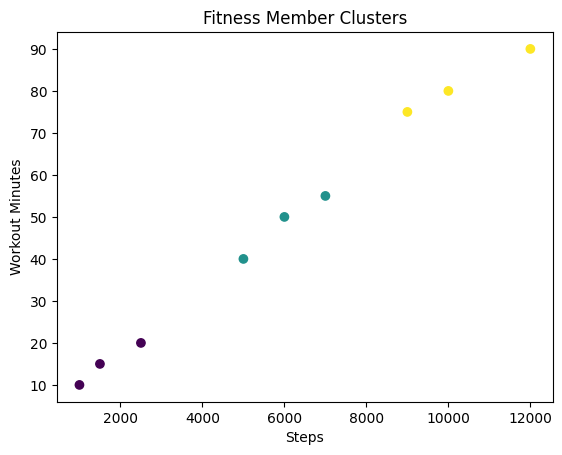

In [3]:
# ============================================
# FITNESS MEMBER SEGMENTATION PROJECT
# K-Means + Metrics
# ============================================

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score
)


# ============================================
# Create Dataset
# ============================================

data = {

'Steps':
[1000,1500,2500,
5000,6000,7000,
9000,10000,12000],


'Workout_Minutes':
[10,15,20,
40,50,55,
75,80,90],


'Actual_Label':
[0,0,0,
1,1,1,
2,2,2]

}

df = pd.DataFrame(data)

print("\nOriginal Dataset\n")

print(df)


# ============================================
# Select Input Features
# ============================================

X = df[['Steps','Workout_Minutes']]


# ============================================
# Train K-Means
# ============================================

model = KMeans(
    n_clusters=3,
    random_state=42
)

model.fit(X)


# ============================================
# Predict Clusters
# ============================================

predicted = model.labels_

df['Predicted'] = predicted


print("\nPredicted Clusters\n")

print(predicted)


# ============================================
# IMPORTANT:
# K-Means labels are random
# ============================================

print("\nCluster Centers\n")

print(model.cluster_centers_)


# Actual learned clusters:

# Cluster 2 → Low
# Cluster 0 → Medium
# Cluster 1 → High


cluster_mapping = {

2:0,
0:1,
1:2

}


df['Mapped_Predicted'] = (
    df['Predicted']
    .map(cluster_mapping)
)


# Human-friendly labels

activity_map = {

0:'Low Activity',
1:'Medium Activity',
2:'High Activity'

}


df['Activity_Level']=(
    df['Mapped_Predicted']
    .map(activity_map)
)


print("\nUpdated Dataset\n")

print(df)


# ============================================
# Evaluation
# ============================================

accuracy = accuracy_score(

    df['Actual_Label'],

    df['Mapped_Predicted']

)


precision = precision_score(

    df['Actual_Label'],

    df['Mapped_Predicted'],

    average='macro'

)


recall = recall_score(

    df['Actual_Label'],

    df['Mapped_Predicted'],

    average='macro'

)


print("\nAccuracy:",accuracy)

print("Precision:",precision)

print("Recall:",recall)


# ============================================
# Visualization
# ============================================

plt.scatter(

    df['Steps'],

    df['Workout_Minutes'],

    c=df['Mapped_Predicted']

)

plt.xlabel("Steps")

plt.ylabel("Workout Minutes")

plt.title(
    "Fitness Member Clusters"
)

plt.show()